In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm import tqdm
import sys


sys.path.insert(0,'/content/drive/MyDrive/Wunderfund/')
import utils
import myfunc as mf

In [ ]:
def get_vecs(dataset, start_index, end_index, history_size, target_size):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i)
    # Reshape data from (history_size,) to (history_size, 1)
    # data.append(np.reshape(dataset[indices], (history_size, 1)))
    data.append(dataset.iloc[indices])
    labels.append(dataset.iloc[i+target_size])
  return np.array(data), np.array(labels)

In [ ]:
df = pd.read_parquet("/content/drive/MyDrive/Wunderfund/datasets/train.parquet")

In [ ]:
ft = [str(i) for i in range(32)]
df[ft] = df[ft].astype('float32')

In [ ]:
beg = 400
hist = 101
tr_bond = 470
end = 517

In [ ]:
a = df.query("seq_ix == 437")
a.to_csv("/content/drive/MyDrive/Wunderfund/datasets/s437.csv", columns=a.columns)

In [ ]:
a = df.query(f"seq_ix == {beg}").iloc[:,3:]
X, Y = get_vecs(a, 0, None, hist, 0)
for seq_ix in tqdm(range(beg+1, tr_bond)):
  a = df.query(f"seq_ix == {seq_ix}").iloc[:,3:]
  x, y = get_vecs(a, 0, None, hist, 0)

  X = np.concatenate((X, x))
  Y = np.concatenate((Y, y))

100%|██████████| 69/69 [01:04<00:00,  1.07it/s]


In [ ]:
a = df.query(f"seq_ix == {tr_bond}").iloc[:,3:]
U, V = get_vecs(a, 0, None, hist, 0)
for seq_ix in tqdm(range(tr_bond+1, end)):
  a = df.query(f"seq_ix == {seq_ix}").iloc[:,3:]
  x, y = get_vecs(a, 0, None, hist, 0)

  U = np.concatenate((U, x))
  V = np.concatenate((V, y))

100%|██████████| 46/46 [00:42<00:00,  1.08it/s]


In [ ]:
X.shape, Y.shape

((120466, 101, 32), (120466, 32))

In [ ]:
BATCH_SIZE = 256
BUFFER_SIZE = 10000

tr = tf.data.Dataset.from_tensor_slices((X, Y))
tr = tr.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val = tf.data.Dataset.from_tensor_slices((U, V))
val_ = val.batch(BATCH_SIZE).repeat()

In [ ]:
model= tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, input_shape=X.shape[-2:]),
    tf.keras.layers.Dense(32)
])
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model= tf.keras.models.Sequential([
    tf.keras.layers.GRU(64, input_shape=X.shape[-2:], return_sequences=True),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(32),
])
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
for x, y in val_.take(1):
    print(model.predict(x).shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
(256, 32)


In [ ]:
EVALUATION_INTERVAL = 500
EPOCHS = 5

model.fit(tr, epochs=EPOCHS,
          steps_per_epoch=EVALUATION_INTERVAL,
          validation_data=val_, validation_steps=50)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.6550 - val_loss: 0.7849
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.6402 - val_loss: 0.7921
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.6407 - val_loss: 0.7953
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.6289 - val_loss: 0.8140
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.6190 - val_loss: 0.8203


In [ ]:
rg = [*range(250, 260)]
x_, y_true = get_vecs(df.query(f"seq_ix in {rg}").iloc[:,3:], 0, None, hist, 0)

In [ ]:
y_pred = model.predict(x_)

310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
x_.shape

(899, 101, 32)

In [ ]:
metric = tf.keras.metrics.R2Score()
metric.update_state(y_true, y_pred)
result = metric.result()
print(result)

tf.Tensor(0.36744377, shape=(), dtype=float32)


In [ ]:
model.save("/content/drive/MyDrive/Wunderfund/model2810_2.keras")

In [ ]:
from utils import DataPoint, ScorerStepByStep

# no need get_vecs here

class PredictionModel:

    def __init__(self):
        self.current_seq_ix = None
        self.sequence_history = []
        self.model = tf.keras.models.load_model('/content/drive/MyDrive/Wunderfund/model1610.keras')

    def predict(self, data_point: DataPoint) -> np.ndarray:
        if self.current_seq_ix != data_point.seq_ix:
            self.current_seq_ix = data_point.seq_ix
            self.sequence_history = []

        self.sequence_history.append(data_point.state.copy().reshape(1, 32))
        if len(self.sequence_history) > 101:
          self.sequence_history = self.sequence_history[1:]

        if not data_point.need_prediction:
            return None

        x = np.concatenate(self.sequence_history)
        global DEBUG
        DEBUG = x
        y_pred = self.model.predict(x.reshape(1, 101, 32))

        return y_pred

In [ ]:
test = df.query("seq_ix == 270")
test.iloc[0].tolist()
test

,seq_ix,step_in_seq,need_prediction,0,1,2,3,4,5,6,...,22,23,24,25,26,27,28,29,30,31
270000,270,0,0,-0.334903,-0.760970,-1.038966,1.552541,1.528939,-1.061292,1.281032,...,-1.121016,0.897412,-0.632760,-1.309801,-0.123982,1.528006,-0.985227,-0.864807,-0.006331,0.392123
270001,270,1,0,-0.703933,-0.550026,-1.503438,0.642229,0.736466,-0.521963,0.441445,...,-0.086027,0.320624,-0.453877,-0.069006,-0.547075,0.886097,-0.722003,0.089639,0.506229,-0.373262
270002,270,2,0,-0.114642,-1.309667,-0.747165,1.020172,0.710522,-1.240543,0.428330,...,-0.687824,1.279566,0.173224,-0.678208,0.348668,1.084374,-1.649153,0.419629,-0.269582,-0.052421
270003,270,3,0,-0.743310,-0.355791,-1.532633,0.667834,0.931709,-0.453349,0.658751,...,-0.152535,0.209245,-0.732594,-0.245221,-0.635681,0.855130,-0.469439,-0.461174,0.545803,-0.299584
270004,270,4,0,1.001466,-0.375727,1.107551,-0.133553,-0.775723,-0.239496,-0.941139,...,-0.284855,0.452530,1.719223,0.263976,1.432842,-0.240717,-0.686867,1.558790,-0.850752,0.675827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270995,270,995,1,-0.120608,-0.972879,-1.075228,1.559901,1.335582,-1.070255,1.079844,...,-1.259360,1.206125,-0.209581,-1.365846,-0.034447,1.560489,-1.276043,-0.563024,-0.085260,0.341425
270996,270,996,1,-0.123563,-0.755203,-1.073998,1.650710,1.529332,-0.947390,1.279584,...,-1.378712,1.134342,-0.453124,-1.597997,-0.173059,1.568372,-0.983371,-0.896282,-0.049945,0.427092
270997,270,997,1,-0.217786,-0.826823,-1.167348,1.372877,1.267474,-0.908715,1.006687,...,-1.040275,0.993571,-0.306076,-1.141022,-0.200991,1.409990,-1.092007,-0.546339,0.075093,0.230844
270998,270,998,1,0.818945,0.061724,0.528470,0.619390,0.163959,-0.018386,0.217769,...,-1.381276,0.152830,0.882566,-0.532447,0.561798,0.321643,-0.125795,0.383699,-0.273644,1.658021


In [ ]:
from time import sleep
md = PredictionModel()

for i in range(100):
  line = test.iloc[i].tolist()
  dp = DataPoint(int(line[0]), int(line[1]), bool(line[2]), np.array(line[3:]))
  y_pred = md.predict(dp)
  assert y_pred is None


y_pred = []
y_true = []
for i in range(100, 300):
  line = test.iloc[i].tolist()
  dp = DataPoint(int(line[0]), int(line[1]), bool(line[2]), np.array(line[3:]))
  if i < 299:
    y_pred.append(md.predict(dp))
  if i > 100:
    y_true.append(np.array(line[3:]).reshape(1, 32))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━

In [ ]:
line = test.iloc[100].tolist()
dp = DataPoint(int(line[0]), int(line[1]), bool(line[2]), np.array(line[3:]))
res = md.predict(dp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


In [ ]:
res

array([[-0.6021076 ,  0.19619045, -0.4912603 , -0.3166883 , -0.04927041,
         0.26371974, -0.24284789, -0.37463713,  0.05579334,  0.6852431 ,
         0.31179732,  0.810109  , -0.11559338, -0.01618563,  0.56714624,
        -0.57089823, -0.6328089 ,  0.2015808 ,  0.14893821, -0.44653472,
         0.44639838,  0.37467438,  0.46491832, -0.5553571 , -0.3804425 ,
         0.7343023 , -0.72091436,  0.01748052,  0.18066564,  0.4593153 ,
         0.83369815, -0.58974063]], dtype=float32)

In [ ]:
YP = np.concatenate(y_pred)
YT = np.concatenate(y_true)

In [ ]:
u, v = get_vecs(test.iloc[:,3:], 0, 300, 101, 0)

# Конвертация модели

In [ ]:
!pip install tf2onnx==1.16.1
!pip install numpy==1.26.4
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.7 MB/s eta 0:00:00


In [ ]:
import tf2onnx

model = tf.keras.models.load_model('/content/drive/MyDrive/Wunderfund/model1610.keras')

if isinstance(model, tf.keras.Sequential):
    input_shape = model.input_shape
    if isinstance(input_shape, list):
        input_shape = input_shape[0]

    input_layer = tf.keras.layers.Input(shape=input_shape[1:], name='input')
    x = input_layer
    for layer in model.layers:
        x = layer(x)
    functional_model = tf.keras.Model(inputs=input_layer, outputs=x)
else:
    functional_model = model

input_signature = [tf.TensorSpec(functional_model.inputs[0].shape, tf.float32, name='input')]

# Конвертация в ONNX
try:
    onnx_model, _ = tf2onnx.convert.from_keras(functional_model, input_signature, opset=13)
except Exception as e:
    print(f"Ошибка при конвертации: {e}")
    onnx_model = tf2onnx.convert.from_keras(functional_model, opset=13).model

# Сохрание ONNX-модели
with open('model.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

print("Модель успешно конвертирована в ONNX!")

Модель успешно конвертирована в ONNX!


In [ ]:
arr = np.random.uniform(low=-4, high=4, size=(1, 101, 32))
arr.astype(np.float32)

array([[[-2.7224104 ,  0.87403053, -0.9879388 , ..., -2.1003194 ,
          2.8352053 , -3.6697145 ],
        [-2.66312   ,  2.9160104 , -3.7732613 , ...,  3.7693112 ,
         -1.3355721 , -3.172083  ],
        [-0.0690366 , -1.8936079 ,  0.71099347, ..., -3.349558  ,
          0.4615704 ,  0.16132884],
        ...,
        [-0.29708773,  0.84661573, -1.4135214 , ...,  0.2379919 ,
         -3.6334987 , -3.7053602 ],
        [-3.043251  ,  0.6403226 ,  2.9856362 , ..., -1.4868443 ,
         -0.5694179 ,  3.5733755 ],
        [-2.4846847 ,  3.319714  , -2.3531642 , ..., -1.6161909 ,
         -1.330316  ,  1.3971671 ]]], dtype=float32)

In [ ]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession('model.onnx')

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name
dummy_input = arr.astype(np.float32)

result = session.run([output_name], {input_name: dummy_input})
print(result[0])

[[-0.0957287  -0.3995035   0.38458288 -0.45035303 -0.639998    0.01625744
   0.35706112 -0.47831994 -1.0193859  -0.02479193 -0.7381677  -0.5997617
  -0.09695169  0.7424393   0.04684791  0.4256508   0.38486814 -0.04358703
   0.32343552 -0.46514383  1.1930702   0.09150203  1.0575473  -0.09300077
  -0.6554262   0.23444402  0.5480801  -0.6803634   0.10558372 -0.4640274
  -1.1171516  -0.92183125]]


In [ ]:
yo = result[0]
yt = model.predict(arr.astype(np.float32))
np.linalg.norm(yo[0] - yt[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


9.741545e-07

# Исследование исходных данных

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
seq_ix,517000.0,258.000000,149.244910,0.000000,129.000000,258.000000,387.000000,516.000000
step_in_seq,517000.0,499.500000,288.675269,0.000000,249.750000,499.500000,749.250000,999.000000
need_prediction,517000.0,0.899000,0.301329,0.000000,1.000000,1.000000,1.000000,1.000000
0,517000.0,0.001247,0.985075,-5.199337,-0.672111,-0.003134,0.655925,5.199337
1,517000.0,0.022680,0.994030,-5.199337,-0.655956,0.013809,0.698124,5.199337
2,517000.0,-0.006079,1.008094,-5.199337,-0.680784,-0.006287,0.663186,5.199337
3,517000.0,-0.013578,1.010944,-5.199337,-0.703100,-0.020027,0.661700,5.199337
4,517000.0,-0.001519,0.990853,-5.199337,-0.684677,-0.003576,0.670718,5.199337
5,517000.0,0.006435,0.989786,-5.199337,-0.668105,0.009730,0.685277,5.199337
6,517000.0,-0.022507,1.001207,-5.199337,-0.709381,-0.018166,0.669402,5.199337


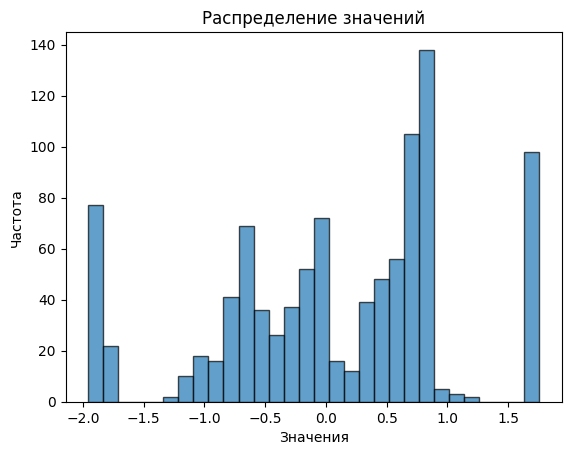

In [ ]:
df.query("seq_ix == 37")['17'].plot.hist(bins=30, alpha=0.7, edgecolor='black')
plt.title('Распределение значений')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.show()